**Student:** Aimen A Ali Etorki

**Student Number: 30095294**

**Year:** Feb 2025 Intake

**Supervisor:** Dr Mabrouka Abuhmida

**MSc Project:** CS4T702_2025/26 Artificial Intelligence 

**Project Title:**  Explainable Hybrid AI Model for Early Detection of Alzheimer’s Disease Using MRI-Derived Hippocampal and Brain Structural Features

# Notebook 1: ADNI Data Exploration

## Dissertation Project

**Title:** Explainable Hybrid AI Model for Early Detection of Alzheimer's Disease Using MRI-Derived Hippocampal and Brain Structural Features

---

## Objective

This notebook explores the ADNI dataset and establishes the participant cohort used throughout the project. It examines the available metadata, diagnostic class distribution and demographic characteristics, verifies the availability of MRI data, and checks the structure and consistency of the dataset before preprocessing and model development.

## Data Exploration and Validation

The analysis includes:

* **Cohort characterisation.** The number of participants and MRI records is examined across the CN, MCI and AD diagnostic groups to understand the composition and class balance of the dataset.

* **Demographic analysis.** Age and sex distributions are examined across diagnostic groups to identify potential demographic differences that could influence subsequent model development and interpretation.

* **Participant consistency.** Participant identifiers and diagnostic labels are checked for missing values, duplicates and conflicting diagnoses.

* **Longitudinal structure.** Repeated MRI examinations from the same participant are identified so that subsequent dataset splitting can be performed at participant level and data leakage between training, validation and test sets can be prevented.

* **MRI data validation.** The metadata are compared with the available MRI data to confirm that the participants selected for analysis have corresponding imaging records.

* **Participant manifest.** A validated participant-level manifest is prepared for use in the subsequent data processing and modelling stages.


In [1]:
# ============================================================
# Project Configuration
#
# The project root is identified automatically so that file paths
# remain relative to the project structure rather than depending
# on a specific computer or user directory.
# ============================================================

from pathlib import Path


def find_project_root(marker_folders=("MRI 1.5T & 3T Dataset", "notebooks")):
    """Walk upwards until a folder containing the project markers is found."""

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if any((candidate / m).exists() for m in marker_folders):
            return candidate

    # Fall back to the original absolute path
    return Path(r"C:\Users\aimen\Documents\GitHub\MSc-Final-Project")


PROJECT_ROOT = find_project_root()

RAW_DATA = PROJECT_ROOT / "MRI 1.5T & 3T Dataset"
MRI_FOLDER = RAW_DATA / "ADNI"

CSV_FILE = PROJECT_ROOT / "MRI_1.5T___3T_Dataset_7_08_2026.csv"

PROCESSED_DATA = PROJECT_ROOT / "processed"
DATASET_FOLDER = PROJECT_ROOT / "dataset"
FINAL_DATASET_FOLDER = PROJECT_ROOT / "final_dataset"
MODELS_FOLDER = PROJECT_ROOT / "models"
RESULTS_FOLDER = PROJECT_ROOT / "results"
SRC_FOLDER = PROJECT_ROOT / "src"

for folder in [PROCESSED_DATA, DATASET_FOLDER, FINAL_DATASET_FOLDER,
               MODELS_FOLDER, RESULTS_FOLDER, SRC_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["CN", "MCI", "AD"]
RANDOM_SEED = 42

print("PROJECT_ROOT :", PROJECT_ROOT)
print()
print("Path check")
print("-" * 46)
for label, path in [
    ("MRI folder    ", MRI_FOLDER),
    ("Metadata CSV  ", CSV_FILE),
    ("Processed     ", PROCESSED_DATA),
    ("Final dataset ", FINAL_DATASET_FOLDER),
    ("Source module ", SRC_FOLDER),
]:
    status = "OK " if path.exists() else "MISSING"
    print(f"{label}: [{status}] {path}")

PROJECT_ROOT : C:\Users\aimen\Documents\GitHub\MSc-Final-Project

Path check
----------------------------------------------
MRI folder    : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI 1.5T & 3T Dataset\ADNI
Metadata CSV  : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI_1.5T___3T_Dataset_7_08_2026.csv
Processed     : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\processed
Final dataset : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\final_dataset
Source module : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src


In [2]:
# ============================================================
# Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.1 Load and Inspect the Metadata

In [3]:
# ============================================================
# Load ADNI Metadata
# ============================================================

if not CSV_FILE.exists():
    raise FileNotFoundError(
        f"Metadata CSV not found at {CSV_FILE}. "
        f"Check that PROJECT_ROOT is set correctly."
    )

df = pd.read_csv(CSV_FILE)

print("Metadata loaded.")
print("Shape :", df.shape)
print()
print("Columns:")
for column in df.columns:
    print(f"  {column:<16} {str(df[column].dtype):<10} "
          f"{df[column].nunique():>4} unique")

display(df.head())

Metadata loaded.
Shape : (520, 12)

Columns:
  Image Data ID    str         520 unique
  Subject          str         411 unique
  Group            str           3 unique
  Sex              str           2 unique
  Age              int64        35 unique
  Visit            str           2 unique
  Modality         str           1 unique
  Description      str           1 unique
  Type             str           1 unique
  Acq Date         str         266 unique
  Format           str           1 unique
  Downloaded       float64       0 unique


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I8850,067_S_0045,MCI,M,86,sc,MRI,MPRAGE,Original,11/16/2005,DCM,NaN
1,I8314,011_S_0023,CN,M,72,sc,MRI,MPRAGE,Original,10/31/2005,DCM,NaN
2,I8248,023_S_0030,MCI,F,80,bl,MRI,MPRAGE,Original,10/26/2005,DCM,NaN
3,I8224,099_S_0040,CN,M,73,sc,MRI,MPRAGE,Original,10/24/2005,DCM,NaN
4,I7161,022_S_0007,AD,M,75,sc,MRI,MPRAGE,Original,9/13/2005,DCM,NaN


In [4]:
# ============================================================
# Data Quality Check
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing values")
print("-" * 46)
if len(missing) == 0:
    print("None.")
else:
    print(missing.to_string())

print()
print("Duplicate rows :", df.duplicated().sum())

# ------------------------------------------------------------
# Confirm that the required metadata columns are present
# ------------------------------------------------------------

REQUIRED_COLUMNS = ["Subject", "Group", "Age", "Sex", "Visit", "Acq Date"]

absent = [c for c in REQUIRED_COLUMNS if c not in df.columns]

if absent:
    raise KeyError(f"Required columns missing from metadata: {absent}")

print()
print("All required columns present:", REQUIRED_COLUMNS)

Missing values
----------------------------------------------
Downloaded    520

Duplicate rows : 0

All required columns present: ['Subject', 'Group', 'Age', 'Sex', 'Visit', 'Acq Date']


## 1.2 Cohort Composition

Two counts are reported because they represent different levels of the dataset:

* **Scan records** — one row per MRI acquisition.
* **Unique participants** — the unit used for participant-level dataset splitting.

Reporting scan-level counts as if they were participant counts would overstate the effective sample size. Both scan-level and participant-level counts are therefore presented below.


In [5]:
# ============================================================
# Scans vs Participants
# ============================================================

total_scans = len(df)
unique_participants = df["Subject"].nunique()

print(f"MRI scan records    : {total_scans}")
print(f"Unique participants : {unique_participants}")
print(f"Repeated scans      : {total_scans - unique_participants}")

# ------------------------------------------------------------
# Participants contributing more than one scan
# ------------------------------------------------------------

scan_counts = df["Subject"].value_counts()
repeated = scan_counts[scan_counts > 1]

if len(repeated) > 0:
    print(f"\n{len(repeated)} participants have multiple scans:")
    display(
        repeated.reset_index()
        .rename(columns={"index": "Participant",
                         "count": "Scans"})
    )
    
    print("These participants are kept within a single dataset split to")
    print("prevent participant-level data leakage in Notebook 4.")
else:
    print("\nEvery participant contributes exactly one scan.")

MRI scan records    : 520
Unique participants : 411
Repeated scans      : 109

101 participants have multiple scans:


,Subject,Scans
0,032_S_0187,4
1,032_S_0677,3
2,013_S_0996,3
3,051_S_1072,3
4,032_S_1101,3
...,...,...
96,067_S_1253,2
97,013_S_1276,2
98,133_S_0638,2
99,051_S_1331,2


These participants are kept within a single dataset split to
prevent participant-level data leakage in Notebook 4.


,Scans,Participants,Participant %
Group,,,
CN,148,117,28.5
MCI,257,201,48.9
AD,115,93,22.6


Majority-class baseline (participant level): 0.4891

This participant-level majority baseline provides a reference
for interpreting later classification accuracy. Predicting the
majority class for every participant would achieve
48.9% accuracy.


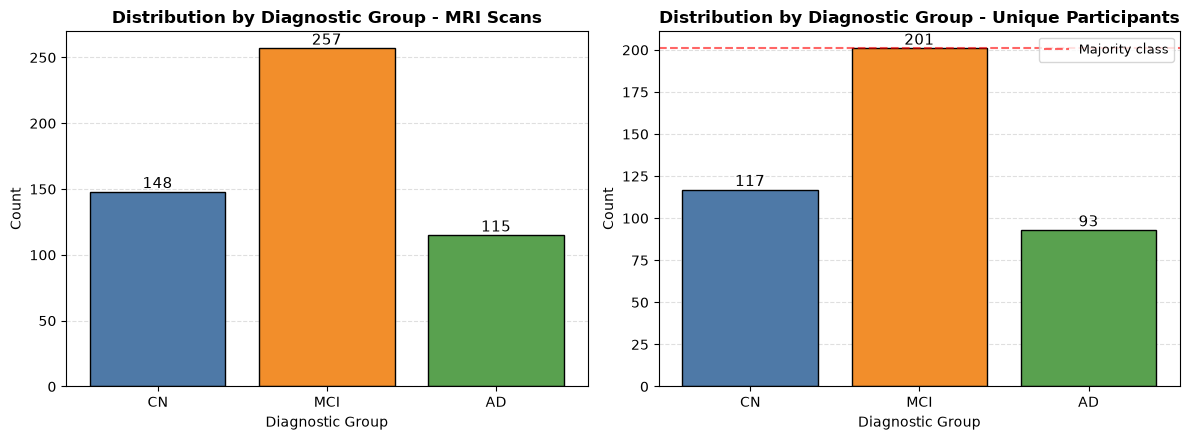

In [7]:
# ============================================================
# Diagnostic Group Distribution
# ============================================================

# Scan level
scan_counts = df["Group"].value_counts().reindex(CLASS_NAMES)

# Participant level - used for model evaluation
participant_table = (
    df[["Subject", "Group"]]
    .drop_duplicates(subset="Subject")
)

participant_counts = (
    participant_table["Group"].value_counts().reindex(CLASS_NAMES)
)

summary = pd.DataFrame({
    "Scans": scan_counts,
    "Participants": participant_counts,
})

summary["Participant %"] = (
    summary["Participants"] / summary["Participants"].sum() * 100
).round(1)

display(summary)

majority = participant_counts.max() / participant_counts.sum()

print(f"Majority-class baseline (participant level): {majority:.4f}")
print()
print("This participant-level majority baseline provides a reference")
print("for interpreting later classification accuracy. Predicting the")
print("majority class for every participant would achieve")
print(f"{majority:.1%} accuracy.")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = ["#4E79A7", "#F28E2B", "#59A14F"]

for ax, series, title in [
    (axes[0], scan_counts, "MRI Scans"),
    (axes[1], participant_counts, "Unique Participants"),
]:
    bars = ax.bar(
        series.index,
        series.values,
        color=colors,
        edgecolor="black"
    )

    ax.bar_label(bars, fontsize=11)

    ax.set_title(
        f"Distribution by Diagnostic Group - {title}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Diagnostic Group")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

axes[1].axhline(
    participant_counts.max(),
    color="red",
    ls="--",
    alpha=0.6,
    label="Majority class"
)

axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 1.3 Demographic Confounds

Age is a major risk factor for Alzheimer's disease, and brain volume also declines with normal ageing. If the AD group in this cohort is materially older than the CN group, a model trained on structural MRI may partially distinguish the groups using age-related atrophy rather than disease-specific pathology. This represents a potential confounding effect and should therefore be quantified before interpreting classification performance.

Sex is examined for a similar reason. Intracranial volume differs systematically between males and females, so an imbalanced sex distribution across diagnostic groups could introduce an additional source of confounding.

Tests used:

* **Age across three groups** — one-way ANOVA if the relevant normality assumptions are reasonably satisfied; Kruskal–Wallis otherwise.
* **Sex against diagnostic group** — chi-square test of independence.


In [30]:
# ============================================================
# Age Distribution by Diagnostic Group
# ============================================================

# Work at participant level - a participant with two scans should
# not contribute their age twice.
demographics = (
    df[["Subject", "Group", "Age", "Sex"]]
    .drop_duplicates(subset="Subject")
    .copy()
)

age_summary = (
    demographics
    .groupby("Group")["Age"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reindex(CLASS_NAMES)
    .round(2)
)

print("Age by diagnostic group (participant level)")
display(age_summary)

# ------------------------------------------------------------
# Test for a group difference in age
# ------------------------------------------------------------

age_groups = [
    demographics.loc[demographics["Group"] == g, "Age"].values
    for g in CLASS_NAMES
]

# Check normality within each group before choosing the test
normality_p = [
    stats.shapiro(group).pvalue if len(group) >= 3 else np.nan
    for group in age_groups
]

print("Shapiro-Wilk normality p-values:")
for name, p in zip(CLASS_NAMES, normality_p):
    verdict = "normal" if (p is not np.nan and p > 0.05) else "non-normal"
    print(f"  {name:<4}: p = {p:.4f}  ({verdict})")

all_normal = all(p > 0.05 for p in normality_p if p is not np.nan)

if all_normal:
    statistic, p_value = stats.f_oneway(*age_groups)
    test_name = "One-way ANOVA"
else:
    statistic, p_value = stats.kruskal(*age_groups)
    test_name = "Kruskal-Wallis"

print()
print(f"{test_name}: statistic = {statistic:.4f}, p = {p_value:.4f}")

if p_value < 0.05:
    print()
    print("SIGNIFICANT age difference between diagnostic groups.")
    print("This is a confound. Structural differences the models detect may")
    print("partly reflect age rather than disease. State this in the")
    print("limitations, and consider reporting age-adjusted results.")
else:
    print()
    print("No significant age difference between groups.")
    print("Age is unlikely to be driving classification performance.")

Age by diagnostic group (participant level)


,count,mean,std,min,median,max
Group,,,,,,
CN,117,76.02,5.58,60,76.0,89
MCI,201,75.28,7.21,55,76.0,89
AD,93,76.53,7.47,57,77.0,91


Shapiro-Wilk normality p-values:
  CN  : p = 0.0167  (non-normal)
  MCI : p = 0.0116  (non-normal)
  AD  : p = 0.0747  (normal)

Kruskal-Wallis: statistic = 1.9239, p = 0.3821

No significant age difference between groups.
Age is unlikely to be driving classification performance.


In [31]:
# ============================================================
# Pairwise Age Comparisons
#
# Only informative if the omnibus test above was significant.
# Bonferroni correction applied for the three pairwise tests.
# ============================================================

from itertools import combinations

pairwise = []

for group_a, group_b in combinations(CLASS_NAMES, 2):

    values_a = demographics.loc[demographics["Group"] == group_a, "Age"]
    values_b = demographics.loc[demographics["Group"] == group_b, "Age"]

    if all_normal:
        stat, p = stats.ttest_ind(values_a, values_b, equal_var=False)
        test = "Welch t-test"
    else:
        stat, p = stats.mannwhitneyu(values_a, values_b)
        test = "Mann-Whitney U"

    pairwise.append({
        "Comparison": f"{group_a} vs {group_b}",
        "Test": test,
        "Mean difference": round(values_a.mean() - values_b.mean(), 2),
        "p (raw)": p,
        "p (Bonferroni)": min(1.0, p * 3),
        "Significant": "Yes" if min(1.0, p * 3) < 0.05 else "No",
    })

display(pd.DataFrame(pairwise).round(4))

,Comparison,Test,Mean difference,p (raw),p (Bonferroni),Significant
0,CN vs MCI,Mann-Whitney U,0.74,0.4985,1.0000,No
1,CN vs AD,Mann-Whitney U,-0.51,0.4972,1.0000,No
2,MCI vs AD,Mann-Whitney U,-1.25,0.1729,0.5187,No


In [32]:
# ============================================================
# Sex Distribution by Diagnostic Group
# ============================================================

sex_table = pd.crosstab(demographics["Group"], demographics["Sex"])
sex_table = sex_table.reindex(CLASS_NAMES)

sex_percent = (
    sex_table.div(sex_table.sum(axis=1), axis=0) * 100
).round(1)

print("Sex counts by group")
display(sex_table)

print("Sex percentages by group")
display(sex_percent)

# ------------------------------------------------------------
# Chi-square test of independence
# ------------------------------------------------------------

chi2, chi_p, dof, expected = stats.chi2_contingency(sex_table)

print(f"Chi-square test: chi2 = {chi2:.4f}, dof = {dof}, p = {chi_p:.4f}")

# Chi-square is unreliable when expected cell counts are small
min_expected = expected.min()

if min_expected < 5:
    print(f"\nWARNING: smallest expected cell count is {min_expected:.2f}.")
    print("Chi-square is unreliable below 5. Treat this p-value with caution")
    print("or use Fisher's exact test on a 2x2 subset.")

if chi_p < 0.05:
    print("\nSex distribution differs significantly across groups - a")
    print("potential confound, since intracranial volume differs by sex.")
else:
    print("\nSex is distributed comparably across groups.")

Sex counts by group


Sex,F,M
Group,,
CN,66,51
MCI,81,120
AD,49,44


Sex percentages by group


Sex,F,M
Group,,
CN,56.4,43.6
MCI,40.3,59.7
AD,52.7,47.3


Chi-square test: chi2 = 8.8997, dof = 2, p = 0.0117

Sex distribution differs significantly across groups - a
potential confound, since intracranial volume differs by sex.


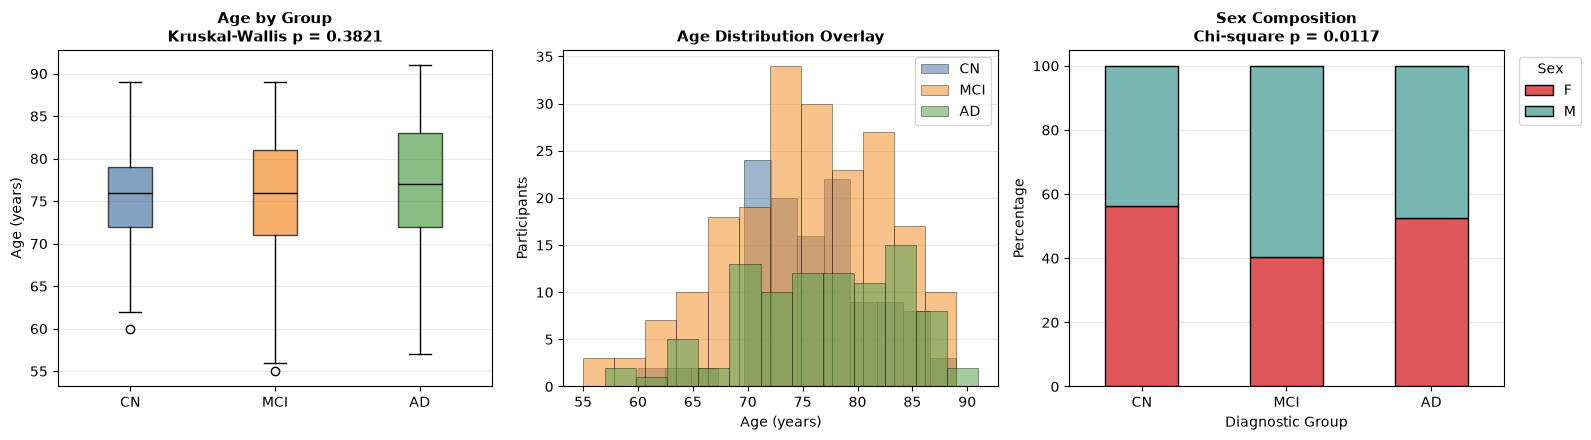

In [35]:
# ============================================================
# Demographic Visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ---- age boxplot ----
box_data = [
    demographics.loc[demographics["Group"] == g, "Age"].values
    for g in CLASS_NAMES
]


bp = axes[0].boxplot(box_data, tick_labels=CLASS_NAMES, patch_artist=True,
                     medianprops={"color": "black"})


for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title(f"Age by Group\n{test_name} p = {p_value:.4f}",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Age (years)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

# ---- age histogram ----
for group, color in zip(CLASS_NAMES, colors):
    axes[1].hist(
        demographics.loc[demographics["Group"] == group, "Age"],
        bins=12, alpha=0.55, label=group, color=color,
        edgecolor="black", linewidth=0.5,
    )

axes[1].set_title("Age Distribution Overlay", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Participants")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

# ---- sex stacked bar ----
sex_percent.plot(kind="bar", stacked=True, ax=axes[2],
                 color=["#E15759", "#76B7B2"], edgecolor="black")

axes[2].set_title(f"Sex Composition\nChi-square p = {chi_p:.4f}",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("Diagnostic Group")
axes[2].set_ylabel("Percentage")
axes[2].set_xticklabels(CLASS_NAMES, rotation=0)
axes[2].legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[2].grid(axis="y", alpha=0.3)
axes[2].set_axisbelow(True)

plt.tight_layout()
plt.show()

## 1.4 Label Consistency

Before diagnostic labels are used for supervised learning, two aspects of label consistency are examined:

1. **Conflicting diagnoses across scans.** A participant may have multiple MRI records collected at different visits, and diagnostic status can change over time. Participants with more than one diagnostic label are therefore identified explicitly so that longitudinal changes are not hidden by simply retaining the first available record.

2. **Visit structure.** The distribution of baseline and follow-up visits is examined to understand how repeated MRI acquisitions and cross-sectional diagnostic labels are represented within the cohort.


In [38]:
# ============================================================
# Check for Conflicting Diagnoses
# ============================================================

diagnosis_counts = df.groupby("Subject")["Group"].nunique()
conflicts = diagnosis_counts[diagnosis_counts > 1]

if len(conflicts) == 0:
    print("No participant has conflicting diagnoses across scans.")
else:
    print(f"{len(conflicts)} participants have MORE THAN ONE diagnosis:")

    conflict_detail = df[df["Subject"].isin(conflicts.index)][
        ["Subject", "Group", "Visit", "Acq Date", "Age"]
    ].sort_values(["Subject", "Acq Date"])

    display(conflict_detail)

    print("These represent diagnostic conversion between visits.")
    print("Decide explicitly which label to use (baseline or latest) rather")
    print("than allowing drop_duplicates() to pick arbitrarily.")

    

No participant has conflicting diagnoses across scans.


In [39]:
# ============================================================
# Visit Structure
# ============================================================

print("Visit codes present:")
display(df["Visit"].value_counts().to_frame("Scans"))

# ------------------------------------------------------------
# Acquisition date range
# ------------------------------------------------------------

df["Acq Date"] = pd.to_datetime(df["Acq Date"])

print(f"Acquisition dates: {df['Acq Date'].min().date()} "
      f"to {df['Acq Date'].max().date()}")

span_years = (df["Acq Date"].max() - df["Acq Date"].min()).days / 365.25
print(f"Span: {span_years:.1f} years")

if span_years > 3:
    print()
    print("Scans span several years. Scanner hardware and software are")
    print("routinely upgraded over such a period, which can introduce")
    print("systematic intensity differences. Notebook 2 checks acquisition")
    print("parameters directly from the DICOM headers.")

# ------------------------------------------------------------
# Description / sequence type
# ------------------------------------------------------------

print()
print("Sequence descriptions:")
display(df["Description"].value_counts().to_frame("Scans"))

Visit codes present:


,Scans
Visit,
sc,378
bl,142


Acquisition dates: 2005-08-26 to 2007-09-24
Span: 2.1 years

Sequence descriptions:


,Scans
Description,
MPRAGE,520


## 1.5 MRI Data Availability

Every participant listed in the metadata must have a corresponding MRI folder on
disk, and every folder on disk should correspond to a listed participant. Both
directions are checked — an unexpected extra folder is as much a problem as a
missing one, because it suggests the metadata and the download are out of step.

In [40]:
# ============================================================
# Cross-Check Metadata Against MRI Folders
# ============================================================

if not MRI_FOLDER.exists():
    raise FileNotFoundError(f"MRI folder not found: {MRI_FOLDER}")

folder_subjects = {
    folder.name
    for folder in MRI_FOLDER.iterdir()
    if folder.is_dir()
}

csv_subjects = set(df["Subject"])

missing_folders = csv_subjects - folder_subjects
extra_folders = folder_subjects - csv_subjects

print(f"Participants in metadata : {len(csv_subjects)}")
print(f"MRI folders on disk      : {len(folder_subjects)}")
print(f"Missing MRI folders      : {len(missing_folders)}")
print(f"Unlisted extra folders   : {len(extra_folders)}")

if missing_folders:
    print("\nMissing MRI data for:")
    for subject in sorted(missing_folders):
        print(f"  {subject}")

if extra_folders:
    print("\nFolders present but not in metadata:")
    for subject in sorted(extra_folders):
        print(f"  {subject}")

# Report whether metadata and MRI folders are consistent
if not missing_folders and not extra_folders:
    print("\nMetadata and MRI folders are fully consistent.")
else:
    print("\nMismatch detected. Only participants with both metadata and")
    print("MRI data will be carried into the dataset built in Notebook 4.")

Participants in metadata : 411
MRI folders on disk      : 411
Missing MRI folders      : 0
Unlisted extra folders   : 0

Metadata and MRI folders are fully consistent.


## 1.6 Export the Verified Participant Manifest

A verified participant manifest is created containing one record per participant,
together with diagnosis, demographic information, and confirmed MRI availability.
Saving this checked cohort provides a consistent participant-level reference for
the subsequent stages of the project.

In [41]:
# ============================================================
# Build and Save the Participant Manifest
# ============================================================

manifest = (
    df.sort_values("Acq Date")
    .drop_duplicates(subset="Subject", keep="first")
    [["Subject", "Group", "Age", "Sex", "Visit", "Acq Date"]]
    .copy()
)

manifest["MRI_Available"] = manifest["Subject"].isin(folder_subjects)

# Retain only participants with usable data
manifest_valid = manifest[manifest["MRI_Available"]].reset_index(drop=True)

print(f"Participants in manifest        : {len(manifest)}")
print(f"With confirmed MRI available    : {len(manifest_valid)}")

print()
print("Final cohort by group:")
display(
    manifest_valid["Group"].value_counts()
    .reindex(CLASS_NAMES).to_frame("Participants")
)

MANIFEST_PATH = PROJECT_ROOT / "participant_manifest.csv"

manifest_valid.to_csv(MANIFEST_PATH, index=False)

print(f"\nSaved: {MANIFEST_PATH}")
print()
print("Note: where a participant has multiple scans, the EARLIEST scan is")
print("kept. This is a deliberate choice - baseline scans give the earliest")
print("point at which detection would be clinically useful. If you prefer")
print("the latest scan, change keep='first' to keep='last' above.")

display(manifest_valid.head(10))

Participants in manifest        : 411
With confirmed MRI available    : 411

Final cohort by group:


,Participants
Group,
CN,117
MCI,201
AD,93



Saved: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\participant_manifest.csv

Note: where a participant has multiple scans, the EARLIEST scan is
kept. This is a deliberate choice - baseline scans give the earliest
point at which detection would be clinically useful. If you prefer
the latest scan, change keep='first' to keep='last' above.


,Subject,Group,Age,Sex,Visit,Acq Date,MRI_Available
0,011_S_0002,CN,74,M,sc,2005-08-26,True
1,011_S_0003,AD,81,M,sc,2005-09-01,True
2,011_S_0005,CN,74,M,sc,2005-09-02,True
3,022_S_0007,AD,75,M,sc,2005-09-13,True
4,011_S_0008,CN,85,F,sc,2005-09-13,True
5,022_S_0004,MCI,68,M,sc,2005-09-22,True
6,011_S_0016,CN,66,M,sc,2005-09-27,True
7,022_S_0014,CN,79,F,sc,2005-09-29,True
8,011_S_0021,CN,73,F,sc,2005-10-10,True
9,023_S_0030,MCI,80,F,sc,2005-10-10,True


In [42]:
# ============================================================
# Exploration Summary
# ============================================================

print("=" * 58)
print("           ADNI DATASET EXPLORATION SUMMARY")
print("=" * 58)

print(f"MRI scan records          : {total_scans}")
print(f"Unique participants       : {unique_participants}")
print(f"Final cohort (MRI + label): {len(manifest_valid)}")

print()
print("Class distribution (participants)")
print("-" * 34)
for group in CLASS_NAMES:
    count = (manifest_valid["Group"] == group).sum()
    print(f"  {group:<4}: {count:>4}  ({count / len(manifest_valid):.1%})")

print(f"\nMajority-class baseline   : {majority:.4f}")

print()
print("Confound checks")
print("-" * 34)
print(f"  Age across groups   : {test_name} p = {p_value:.4f} "
      f"({'CONFOUND' if p_value < 0.05 else 'clear'})")
print(f"  Sex across groups   : chi-square p = {chi_p:.4f} "
      f"({'CONFOUND' if chi_p < 0.05 else 'clear'})")

print()
print("Data integrity")
print("-" * 34)
print(f"  Missing MRI folders : {len(missing_folders)}")
print(f"  Unlisted folders    : {len(extra_folders)}")
print(f"  Label conflicts     : {len(conflicts)}")

print()
print("Sample size caution")
print("-" * 34)
smallest = manifest_valid["Group"].value_counts().min()
smallest_name = manifest_valid["Group"].value_counts().idxmin()
print(f"  Smallest group is {smallest_name} with {smallest} participants.")
print(f"  This limits the precision of every downstream estimate and is")
print(f"  the binding constraint on the whole project.")

print("=" * 58)

           ADNI DATASET EXPLORATION SUMMARY
MRI scan records          : 520
Unique participants       : 411
Final cohort (MRI + label): 411

Class distribution (participants)
----------------------------------
  CN  :  117  (28.5%)
  MCI :  201  (48.9%)
  AD  :   93  (22.6%)

Majority-class baseline   : 0.4891

Confound checks
----------------------------------
  Age across groups   : Kruskal-Wallis p = 0.3821 (clear)
  Sex across groups   : chi-square p = 0.0117 (CONFOUND)

Data integrity
----------------------------------
  Missing MRI folders : 0
  Unlisted folders    : 0
  Label conflicts     : 0

Sample size caution
----------------------------------
  Smallest group is AD with 93 participants.
  This limits the precision of every downstream estimate and is
  the binding constraint on the whole project.


### Next step

Notebook 2 reads the DICOM data directly and verifies MRI acquisition parameters
across the cohort, including scanner manufacturer, field strength, and voxel
spacing, before the preprocessing stages that follow.